<a href="https://colab.research.google.com/github/ramakrishnabhavana/dl-practice/blob/main/DL_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#week1

In [ ]:
pip install keras

In [ ]:
#Simple Neural Network with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
x = torch.randn(100, 3)
y = torch.randn(100, 1)
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
    def forward(self, x):
        return self.linear(x)
model = SimpleNet()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)
for epoch in range(100):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("Final loss:", loss.item())

Final loss: 0.8709965348243713


In [ ]:
# Simple Neural Network with TensorFlow
import tensorflow as tf
x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,
                          input_shape=(3,))
])
model.compile(optimizer='adam',             # Configures the Adam optimizer for training
              loss='mse')

# Train model
model.fit(x, y,                             # Trains the model using input and target data
          epochs=100,                       # Number of training iterations over the dataset
          verbose=0)                        # Suppresses training progress output

print("Final loss:",                       # Prints a message label
      model.evaluate(x, y))                # Evaluates the trained model on the same dataset

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.3640
Final loss: 1.551206350326538


In [ ]:
# IMPLEMENT A SIMPLE PERCEPTRON (Coding a Neuron)

import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))
class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return sigmoid(total)
weights = np.array([0, 1])
bias = 4
n = Neuron(weights, bias)
x = np.array([2, 3])
print(n.feedforward(x))

0.9990889488055994


In [ ]:
#AND gate
import numpy as np
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)
weights = np.array([1, 1])
bias = -1.5
and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
#OR Gate
weights = np.array([1,1])
bias=-0.5
or_gate=Perceptron(weights,bias)
print("\nOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
  print(x,"->",or_gate.predict(np.array(x)))


OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
#xor using step activation
import numpy as np
def step(x):
  return 1 if x>=0 else 0
class XOR_network:
  def __init__(self):
    self.w_or = np.array([1,1])
    self.b_or = -0.5
    self.w_and = np.array([1,1])
    self.b_and = -1.5
    self.w_out=np.array([1,-2])
    self.b_out= -0.5
  def predict(self,x):
    h1 = step(np.dot(self.w_or,x)+self.b_or)
    h2 = step(np.dot(self.w_and,x)+self.b_and)
    output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
    return output
class NOT_gate:
    def __init__(self):
        self.w = -1
        self.b = 0.5
    def predict(self, x):
        return step(self.w * x + self.b)
xor = XOR_network()
not_gate = NOT_gate()
print("XOR and ¬XOR Gates")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    xor_out = xor.predict(np.array(x))
    not_xor_out = not_gate.predict(xor_out)
    print(f"{x} -> XOR: {xor_out}, ¬XOR: {not_xor_out}")

XOR and ¬XOR Gates
(0, 0) -> XOR: 0, ¬XOR: 1
(0, 1) -> XOR: 1, ¬XOR: 0
(1, 0) -> XOR: 1, ¬XOR: 0
(1, 1) -> XOR: 0, ¬XOR: 1


In [ ]:
#XOR Training Using Gradient Descent
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return x * (1 - x)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])
np.random.seed(42)
W1 = np.random.rand(2, 2)
b1 = np.random.rand(1, 2)
W2 = np.random.rand(2, 1)
b2 = np.random.rand(1, 1)
learning_rate = 0.1
epochs = 10000
for epoch in range(epochs):
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(final_input)
    error = y - y_pred
    loss = np.mean(error ** 2)
    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))



Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


#WEEK 2

In [ ]:
#demonstrate thresholding is harsh
import numpy as np
def step(x):
  return 1 if x >= 0 else 0
class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return step(total)
weights = np.array([0, 1])
b_1 = -3.1
b_2 = 2
b_3 = -3.0
n = Neuron(weights, b_1)
n_2 = Neuron(weights, b_2)
n_3 = Neuron(weights,b_3)
x = np.array([2, 3])
print("with bias -3.1:",n.feedforward(x))
print("\nwith bias -3.0:",n_3.feedforward(x))
print("\nwith bias 2:",n_2.feedforward(x))

with bias -3.1: 0

with bias -3.0: 1

with bias 2: 1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
dl = pd.read_csv("/content/dl-week2 - Sheet1.csv")
X = dl['f1','f2','f3','f4']
y=dl['output'].values
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

def step(z):
  return 1 if z>=0 else 0


In [ ]:
# XOR and XNOR implementation using a Multi-Perceptron Network

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Hidden layer perceptrons
def OR(x1, x2):
    w1, w2, b = 1, 1, -0.5
    return step(w1*x1 + w2*x2 + b)

def AND(x1, x2):
    w1, w2, b = 1, 1, -1.5
    return step(w1*x1 + w2*x2 + b)

# XOR using multi-perceptron
def XOR(x1, x2):
    h1 = OR(x1, x2)
    h2 = AND(x1, x2)
    w1, w2, b = 1, -2, -0.5
    return step(w1*h1 + w2*h2 + b)

# XNOR (NOT XOR)
def XNOR(x1, x2):
    return 1 - XOR(x1, x2)

# Testing the network
print("X1 X2 XOR XNOR")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        print(x1, x2, " ", XOR(x1, x2), " ", XNOR(x1, x2))

X1 X2 XOR XNOR
0 0   0   1
0 1   1   0
1 0   1   0
1 1   0   1


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# STEP 1: Create a small movie dataset and save as CSV
# -------------------------------------------------------

data = {
    "MattDamon": [1, 0, 1, 0, 1, 0, 1, 0],
    "Thriller":  [1, 1, 0, 0, 1, 0, 0, 1],
    "Nolan":     [0, 1, 0, 1, 1, 0, 0, 1],
    "IMDB":      [0.9, 0.8, 0.6, 0.4, 0.85, 0.3, 0.7, 0.5],
    "Like":      [1, 1, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
df.to_csv("movies.csv", index=False)

print("Movie Dataset:")
print(df)

X = df.drop("Like", axis=1).values
y = df["Like"].values

# -------------------------------------------------------
# STEP 2: Activation Function
# -------------------------------------------------------

def step(x):
    return 1 if x >= 0 else 0

# -------------------------------------------------------
# i) MP Perceptron (No weights, No bias)
# -------------------------------------------------------

def mp_perceptron_predict(x):
    return step(np.sum(x))   # equal importance to all features

print("\n--- MP Perceptron (No weights, No bias) ---")
for i, x in enumerate(X):
    print(f"Actual: {y[i]}  Predicted: {mp_perceptron_predict(x)}")

# -------------------------------------------------------
# ii) Perceptron with weights only (No bias)
# -------------------------------------------------------

def train_perceptron_no_bias(X, y, lr=0.1, epochs=10):
    w = np.zeros(X.shape[1])
    print("\nTraining Perceptron (Weights only)")
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(X[i], w))
            error = y[i] - y_pred
            if error != 0:
                w = w + lr * error * X[i]
                errors += 1
        print(f"Epoch {epoch+1}, Weights: {w}, Errors: {errors}")
        if errors == 0:
            break
    return w

w_no_bias = train_perceptron_no_bias(X, y)

# -------------------------------------------------------
# iii) Perceptron with weights and bias
# -------------------------------------------------------

def train_perceptron_with_bias(X, y, lr=0.1, epochs=10):
    w = np.zeros(X.shape[1])
    b = 0
    print("\nTraining Perceptron (Weights + Bias)")
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(X[i], w) + b)
            error = y[i] - y_pred
            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error
                errors += 1
        print(f"Epoch {epoch+1}, Weights: {w}, Bias: {b}, Errors: {errors}")
        if errors == 0:
            break
    return w, b

w_bias, b_bias = train_perceptron_with_bias(X, y)

# -------------------------------------------------------
# STEP 3: Test with a sample movie
# -------------------------------------------------------

sample_movie = np.array([1, 1, 0, 0.8])  # Matt Damon, Thriller, Not Nolan, High IMDB

print("\n--- Testing Sample Movie ---")
print("Sample features:", sample_movie)

print("MP Perceptron Prediction:", mp_perceptron_predict(sample_movie))
print("Perceptron (Weights only):", step(np.dot(sample_movie, w_no_bias)))
print("Perceptron (Weights + Bias):", step(np.dot(sample_movie, w_bias) + b_bias))

Movie Dataset:
   MattDamon  Thriller  Nolan  IMDB  Like
0          1         1      0  0.90     1
1          0         1      1  0.80     1
2          1         0      0  0.60     1
3          0         0      1  0.40     0
4          1         1      1  0.85     1
5          0         0      0  0.30     0
6          1         0      0  0.70     1
7          0         1      1  0.50     0

--- MP Perceptron (No weights, No bias) ---
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 1

Training Perceptron (Weights only)
Epoch 1, Weights: [ 0.1    0.    -0.1   -0.035], Errors: 4
Epoch 2, Weights: [ 0.1    0.1   -0.1   -0.025], Errors: 3
Epoch 3, Weights: [ 0.1    0.1   -0.2   -0.065], Errors: 4
Epoch 4, Weights: [ 0.1    0.1   -0.2   -0.065], Errors: 3
Epoch 5, Weights: [ 0.1    0.1   -0.2   -0.065], Errors: 3
Epoch 6, Weights: [ 0.1    0.1   -0.2  

#WEEK-3

In [ ]:
import numpy as np

# Input patterns
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# All 16 Boolean functions (outputs)
boolean_functions = {
    "f1":  [0,0,0,0],
    "f2":  [0,0,0,1],   # AND
    "f3":  [0,0,1,0],
    "f4":  [0,0,1,1],
    "f5":  [0,1,0,0],
    "f6":  [0,1,0,1],
    "f7":  [0,1,1,0],   # XOR
    "f8":  [0,1,1,1],
    "f9":  [1,0,0,0],
    "f10": [1,0,0,1],   # XNOR
    "f11": [1,0,1,0],
    "f12": [1,0,1,1],
    "f13": [1,1,0,0],
    "f14": [1,1,0,1],
    "f15": [1,1,1,0],
    "f16": [1,1,1,1]
}

# Step function
def step(x):
    return 1 if x >= 0 else 0

# Train single perceptron
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        error_count = 0
        for i in range(len(X)):
            y_pred = step(np.dot(X[i], w) + b)
            error = y[i] - y_pred
            if error != 0:
                w += lr * error * X[i]
                b += lr * error
                error_count += 1
        if error_count == 0:
            return True   # Converged

    return False  # Did not converge

# Test all Boolean functions
not_learnable = []

print("Perceptron Learning Results:\n")

for fname, outputs in boolean_functions.items():
    y = np.array(outputs)
    converged = train_perceptron(X, y)
    result = "Learnable" if converged else "NOT Learnable"
    print(f"{fname}: {result}")
    if not converged:
        not_learnable.append(fname)

print("\nSummary:")
print("Total Boolean functions:", len(boolean_functions))
print("Learnable:", len(boolean_functions) - len(not_learnable))
print("Not Learnable:", len(not_learnable))
print("Not Learnable Functions:", not_learnable)

Perceptron Learning Results:

f1: Learnable
f2: Learnable
f3: Learnable
f4: Learnable
f5: Learnable
f6: Learnable
f7: NOT Learnable
f8: Learnable
f9: Learnable
f10: NOT Learnable
f11: Learnable
f12: Learnable
f13: Learnable
f14: Learnable
f15: Learnable
f16: Learnable

Summary:
Total Boolean functions: 16
Learnable: 14
Not Learnable: 2
Not Learnable Functions: ['f7', 'f10']


Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


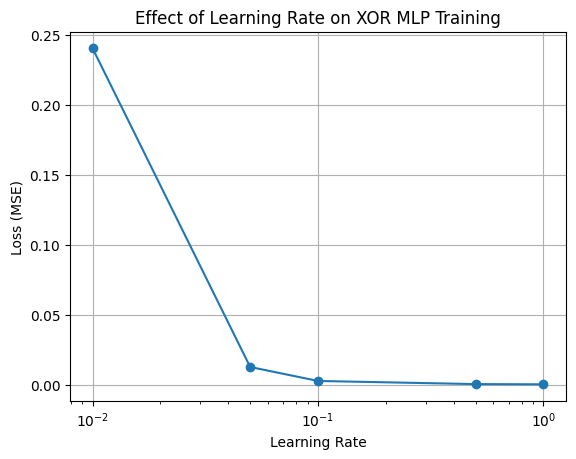

In [ ]:
# MLP for XOR – Effect of Learning Rate on Loss
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return x * (1 - x)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []
epochs = 10000
for lr in learning_rates:
    np.random.seed(42)
    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)
    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)
    for epoch in range(epochs):
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)
        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)
        error = y - y_pred
        loss = np.mean(error ** 2)
        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)
        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")
plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

Epoch 1000, Loss: 0.244429
Epoch 2000, Loss: 0.203598
Epoch 3000, Loss: 0.153406
Epoch 4000, Loss: 0.046398
Epoch 5000, Loss: 0.015627
Epoch 6000, Loss: 0.008452
Epoch 7000, Loss: 0.005615
Epoch 8000, Loss: 0.004148
Epoch 9000, Loss: 0.003264
Epoch 10000, Loss: 0.002679

--- XOR Predictions ---
Input: [0 0] -> Predicted: 0, Actual: 0
Input: [0 1] -> Predicted: 1, Actual: 1
Input: [1 0] -> Predicted: 1, Actual: 1
Input: [1 1] -> Predicted: 0, Actual: 0


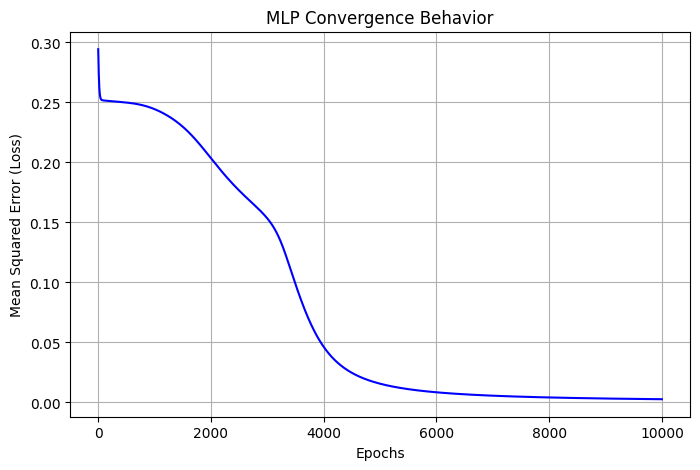


--- Performance Metrics ---
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00


In [ ]:
# 10
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR problem
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# MLP Parameters
# -----------------------------
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
learning_rate = 0.1
epochs = 10000

# Initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.random.randn(1, hidden_neurons)
W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.random.randn(1, output_neurons)

# -----------------------------
# Training with Gradient Descent
# -----------------------------
loss_history = []

for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(final_input)

    # Compute Mean Squared Error loss
    error = y - y_pred
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Backpropagation
    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    # Update weights and biases
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    # Optional: print loss every 1000 epochs
    if (epoch+1) % 1000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.6f}")

# -----------------------------
# Testing the trained MLP
# -----------------------------
hidden_output = sigmoid(np.dot(X, W1) + b1)
y_pred_final = sigmoid(np.dot(hidden_output, W2) + b2)
predictions = (y_pred_final >= 0.5).astype(int)

print("\n--- XOR Predictions ---")
for i in range(len(X)):
    print(f"Input: {X[i]} -> Predicted: {predictions[i][0]}, Actual: {y[i][0]}")

# -----------------------------
# Plot convergence (Loss vs Epochs)
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(loss_history, color='blue')
plt.title("MLP Convergence Behavior")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid(True)
plt.show()

# -----------------------------
# Performance Metrics
# -----------------------------
TP = np.sum((y == 1) & (predictions == 1))
TN = np.sum((y == 0) & (predictions == 0))
FP = np.sum((y == 0) & (predictions == 1))
FN = np.sum((y == 1) & (predictions == 0))

accuracy = (TP + TN) / len(y)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

print("\n--- Performance Metrics ---")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")


In [ ]:
import numpy as np
# Input patterns
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
# All 16 Boolean functions (outputs)
boolean_functions = {
    "f1":  [0,0,0,0],
    "f2":  [0,0,0,1],   # AND
    "f3":  [0,0,1,0],
    "f4":  [0,0,1,1],
    "f5":  [0,1,0,0],
    "f6":  [0,1,0,1],
    "f7":  [0,1,1,0],   # XOR
    "f8":  [0,1,1,1],
    "f9":  [1,0,0,0],
    "f10": [1,0,0,1],   # XNOR
    "f11": [1,0,1,0],
    "f12": [1,0,1,1],
    "f13": [1,1,0,0],
    "f14": [1,1,0,1],
    "f15": [1,1,1,0],
    "f16": [1,1,1,1]
}
# Step function
def step(x):
    return 1 if x >= 0 else 0
# Train single perceptron
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0
    for _ in range(epochs):
        error_count = 0
        for i in range(len(X)):
            y_pred = step(np.dot(X[i], w) + b)
            error = y[i] - y_pred
            if error != 0:
                w += lr * error * X[i]
                b += lr * error
                error_count += 1
        if error_count == 0:
            return True   # Converged

    return False  # Did not converge
# Test all Boolean functions
not_learnable = []
print("Perceptron Learning Results:\n")
for fname, outputs in boolean_functions.items():
    y = np.array(outputs)
    converged = train_perceptron(X, y)
    result = "Learnable" if converged else "NOT Learnable"
    print(f"{fname}: {result}")
    if not converged:
        not_learnable.append(fname)
print("\nSummary:")
print("Total Boolean functions:", len(boolean_functions))
print("Learnable:", len(boolean_functions) - len(not_learnable))
print("Not Learnable:", len(not_learnable))
print("Not Learnable Functions:", not_learnable)

Perceptron Learning Results:

f1: Learnable
f2: Learnable
f3: Learnable
f4: Learnable
f5: Learnable
f6: Learnable
f7: NOT Learnable
f8: Learnable
f9: Learnable
f10: NOT Learnable
f11: Learnable
f12: Learnable
f13: Learnable
f14: Learnable
f15: Learnable
f16: Learnable

Summary:
Total Boolean functions: 16
Learnable: 14
Not Learnable: 2
Not Learnable Functions: ['f7', 'f10']


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

# Create a Perceptron object
perceptron = Perceptron()

# Train the Perceptron on the training data
perceptron.fit(X_train, y_train)

# Use the trained Perceptron to make predictions on the testing data
y_pred = perceptron.predict(X_test)

# Evaluate the accuracy of the Perceptron
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


Training shape: (40000, 3072)
Testing shape: (10000, 3072)
Iteration 1, loss = 2.92809779
Iteration 2, loss = 2.12007155
Iteration 3, loss = 2.09017923
Iteration 4, loss = 2.08519725
Iteration 5, loss = 2.08520959
Iteration 6, loss = 2.07051599
Iteration 7, loss = 2.07038351
Iteration 8, loss = 2.08506210
Iteration 9, loss = 2.06836695
Iteration 10, loss = 2.06649148
Iteration 11, loss = 2.06228495
Iteration 12, loss = 2.06892356
Iteration 13, loss = 2.06144830
Iteration 14, loss = 2.05957538
Iteration 15, loss = 2.05967891
Iteration 16, loss = 2.06112855
Iteration 17, loss = 2.06378443
Iteration 18, loss = 2.05570516
Iteration 19, loss = 2.04755463
Iteration 20, loss = 2.06584353
Iteration 21, loss = 2.05332463
Iteration 22, loss = 2.04806648
Iteration 23, loss = 2.05204546
Iteration 24, loss = 2.05935063
Iteration 25, loss = 2.05097902
Iteration 26, loss = 2.05512230
Iteration 27, loss = 2.05183645
Iteration 28, loss = 2.04589813
Iteration 29, loss = 2.04387004
Iteration 30, loss = 2

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



Basic Model Accuracy (Train): 0.19155
Basic Model Accuracy (Test): 0.1806
Iteration 1, loss = 2.98671810
Iteration 2, loss = 1.89269860
Iteration 3, loss = 1.82544309
Iteration 4, loss = 1.77455806
Iteration 5, loss = 1.75364681
Iteration 6, loss = 1.71946855
Iteration 7, loss = 1.70436862
Iteration 8, loss = 1.68396292
Iteration 9, loss = 1.69641237
Iteration 10, loss = 1.66110685
Iteration 11, loss = 1.66726734
Iteration 12, loss = 1.65797005
Iteration 13, loss = 1.64347577
Iteration 14, loss = 1.64133599
Iteration 15, loss = 1.63623314
Iteration 16, loss = 1.63565856
Iteration 17, loss = 1.61994029
Iteration 18, loss = 1.62619664
Iteration 19, loss = 1.63606637
Iteration 20, loss = 1.61536419
Iteration 21, loss = 1.61214773
Iteration 22, loss = 1.61429768
Iteration 23, loss = 1.60982921
Iteration 24, loss = 1.61971909
Iteration 25, loss = 1.61226958
Iteration 26, loss = 1.60935225
Iteration 27, loss = 1.60589136
Iteration 28, loss = 1.60301819
Iteration 29, loss = 1.59702004
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



Deep Model Accuracy (Train): 0.42765
Deep Model Accuracy (Test): 0.3969
Iteration 1, loss = 3.37223644
Iteration 2, loss = 2.32826506
Iteration 3, loss = 2.32646193
Iteration 4, loss = 2.32489608
Iteration 5, loss = 2.32680417
Iteration 6, loss = 2.32454398
Iteration 7, loss = 2.32335779
Iteration 8, loss = 2.32280397
Iteration 9, loss = 2.32002483
Iteration 10, loss = 2.31908399
Iteration 11, loss = 2.31915769
Iteration 12, loss = 2.31816872
Iteration 13, loss = 2.31861389
Iteration 14, loss = 2.31702329
Iteration 15, loss = 2.31604115
Iteration 16, loss = 2.31599981
Iteration 17, loss = 2.31551033
Iteration 18, loss = 2.31515481
Iteration 19, loss = 2.31554828
Iteration 20, loss = 2.31475537
Iteration 21, loss = 2.31331679
Iteration 22, loss = 2.31310371
Iteration 23, loss = 2.31312566
Iteration 24, loss = 2.31329704
Iteration 25, loss = 2.31412330
Iteration 26, loss = 2.31291959
Iteration 27, loss = 2.31238541
Iteration 28, loss = 2.31057915
Iteration 29, loss = 2.31172935
Iteratio

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



High LR Accuracy (Train): 0.099575
High LR Accuracy (Test): 0.1017
Iteration 1, loss = 2.92809779
Iteration 2, loss = 2.12007155
Iteration 3, loss = 2.09017923
Iteration 4, loss = 2.08519725
Iteration 5, loss = 2.08520959
Iteration 6, loss = 2.07051599
Iteration 7, loss = 2.07038351
Iteration 8, loss = 2.08506210
Iteration 9, loss = 2.06836695
Iteration 10, loss = 2.06649148
Iteration 11, loss = 2.06228495
Iteration 12, loss = 2.06892356
Iteration 13, loss = 2.06144830
Iteration 14, loss = 2.05957538
Iteration 15, loss = 2.05967891
Iteration 16, loss = 2.06112855
Iteration 17, loss = 2.06378443
Iteration 18, loss = 2.05570516
Iteration 19, loss = 2.04755463
Iteration 20, loss = 2.06584353
Iteration 21, loss = 2.05332463
Iteration 22, loss = 2.04806648
Iteration 23, loss = 2.05204546
Iteration 24, loss = 2.05935063
Iteration 25, loss = 2.05097902
Iteration 26, loss = 2.05512230
Iteration 27, loss = 2.05183645
Iteration 28, loss = 2.04589813
Iteration 29, loss = 2.04387004
Iteration 30,

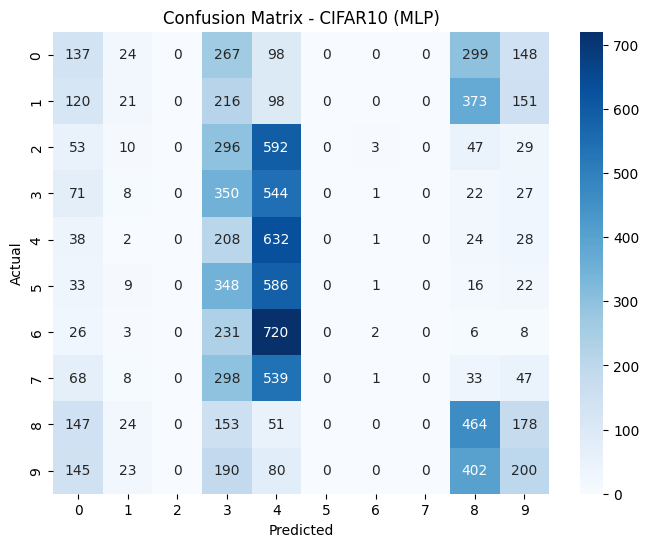

In [ ]:
# Load CIFAR-10 dataset
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# Flatten images (32x32x3 -> 3072)
X = X_train_full.reshape(X_train_full.shape[0], -1)
y = y_train_full.ravel()

# Normalize
X = X / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
# -------------------------------
# 1. Basic MLP Model
# -------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=50,
    learning_rate_init=0.01,
    random_state=1,
    verbose=1
)
mlp.fit(X_train, y_train)
print("\nBasic Model Accuracy (Train):", mlp.score(X_train, y_train))
print("Basic Model Accuracy (Test):", mlp.score(X_test, y_test))
# -------------------------------
# 2. Increase Hidden Layers
# -------------------------------
mlp_deep = MLPClassifier(
    hidden_layer_sizes=(200, 100),
    max_iter=50,
    learning_rate_init=0.01,
    random_state=1,
    verbose=1
)
mlp_deep.fit(X_train, y_train)
print("\nDeep Model Accuracy (Train):", mlp_deep.score(X_train, y_train))
print("Deep Model Accuracy (Test):", mlp_deep.score(X_test, y_test))
# -------------------------------
# 3. Change Learning Rate
# -------------------------------
mlp_lr = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=50,
    learning_rate_init=0.1,   # High learning rate
    random_state=1,
    verbose=1
)
mlp_lr.fit(X_train, y_train)
print("\nHigh LR Accuracy (Train):", mlp_lr.score(X_train, y_train))
print("High LR Accuracy (Test):", mlp_lr.score(X_test, y_test))
# -------------------------------
# 4. Increase Iterations
# -------------------------------
mlp_iter = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=150,   # More iterations
    learning_rate_init=0.01,
    random_state=1,
    verbose=1
)
mlp_iter.fit(X_train, y_train)
print("\nHigh Iter Accuracy (Train):", mlp_iter.score(X_train, y_train))
print("High Iter Accuracy (Test):", mlp_iter.score(X_test, y_test))
# -------------------------------
# Confusion Matrix (Basic Model)
# -------------------------------
preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CIFAR10 (MLP)")
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082
Iteration 8, loss = 0.10957409
Iteration 9, loss = 0.09910434
Iteration 10, loss = 0.09005121
Iteration 11, loss = 0.08238981
Iteration 12, loss = 0.07590413
Iteration 13, loss = 0.06990400
Iteration 14, loss = 0.06552830
Iteration 15, loss = 0.06068202
Iteration 16, loss = 0.05696692
Iteration 17, loss = 0.05327114
Iteration 18, loss = 0.04979526
Iteration 19, loss = 0.04618848
Iteration 20, loss = 0.04420099
Iteration 21, loss = 0.04145133
Iteration 22, loss = 0.03863193
Iteration 23, loss = 0.03670778
Iteration 24, loss = 0.03395817
Iteration 25, loss = 0.03256089
Iteration 26, loss = 0.03003133
Iteration 27, loss = 0.02852477
Iteration 28, loss = 0.02670121
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


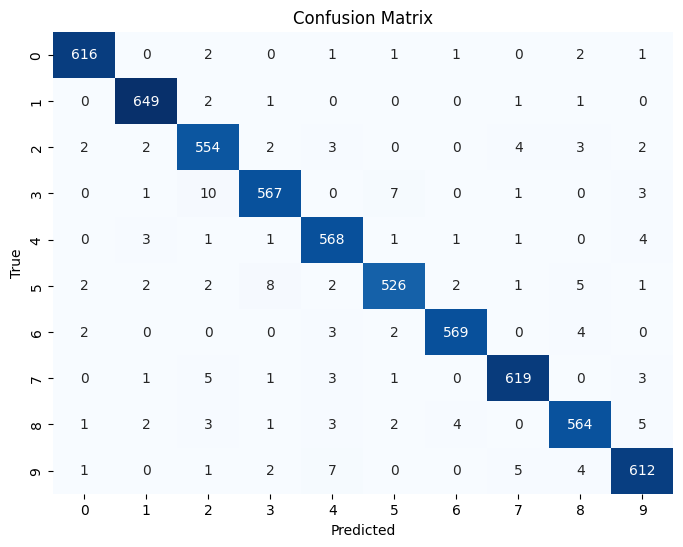

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [ ]:
# Load MNIST dataset
from tensorflow.keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
# Normalize data
X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0
# Flatten images (28x28 -> 784)
X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)
# Train-validation split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
# Train MLP Classifier
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)
mlp.fit(X_train, y_train)
# Accuracy
print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))
# Test single sample
index = 346
test_digit = X_test[index].reshape(1, 784)
prediction = mlp.predict(test_digit)[0]
print("Predicted value:", prediction)
print("Actual value:", y_test[index])
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
# MLP with higher learning rate
mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)
mlp2.fit(X_train, y_train)
print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

In [ ]:
pip install altair

#WEEK 4

In [ ]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
# expected values
y = np.array([[0, 1, 1, 0]]).T
# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T
model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])
history = model.fit(X, y, epochs=1000, verbose=0)
errors = history.history['loss']
df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})
alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')
y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Multi-layer perceptron accuracy: 100.00%


In [ ]:
# Using SGD Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_sgd = Sequential()
model_sgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

model_sgd.compile(loss='mean_squared_error',
                  optimizer=SGD(),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_sgd = model_sgd.fit(X, y, epochs=1000, verbose=0)

errors_sgd = history_sgd.history['loss']

df_sgd = pd.DataFrame({"errors": errors_sgd, "time-step": np.arange(0, len(errors_sgd))})

# Visualization with Altair for SGD optimizer
alt.Chart(df_sgd).mark_line().encode(x="time-step", y="errors").properties(title='SGD Optimizer - Loss Curve')

# Predictions and Accuracy
y_pred_sgd = model_sgd.predict(X).round()
num_correct_predictions_sgd = (y_pred_sgd == y).sum()
accuracy_sgd = (num_correct_predictions_sgd / y.shape[0]) * 100
print('SGD Optimizer accuracy: %.2f%%' % accuracy_sgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
SGD Optimizer accuracy: 50.00%


In [ ]:
# Using SGD Optimizer on Fashion-MNIST

import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Build the model
model_sgd = Sequential()
model_sgd.add(Flatten(input_shape=(28, 28)))
model_sgd.add(Dense(128, activation='relu'))
model_sgd.add(Dense(10, activation='softmax'))

# Compile model using SGD optimizer
model_sgd.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model
history_sgd = model_sgd.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Extract loss values
errors_sgd = history_sgd.history['loss']

# Create DataFrame for visualization
df_sgd = pd.DataFrame({
    "errors": errors_sgd,
    "epoch": np.arange(1, len(errors_sgd) + 1)
})

# Visualization with Altair
alt.Chart(df_sgd).mark_line().encode(
    x="epoch",
    y="errors"
).properties(title="SGD Optimizer - Training Loss Curve (Fashion-MNIST)")
# Evaluate on test data
test_loss, test_accuracy = model_sgd.evaluate(X_test, y_test_cat, verbose=0)
print(f"SGD Optimizer Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5132 - loss: 1.5067 - val_accuracy: 0.7378 - val_loss: 0.7806
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7512 - loss: 0.7543 - val_accuracy: 0.7817 - val_loss: 0.6497
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7892 - loss: 0.6425 - val_accuracy: 0.8012 - val_loss: 0.5862
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8062 - loss: 0.5890 - val_accuracy: 0.8108 - val_loss: 0.5518
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8159 - loss: 0.5500 - val_accuracy: 0.8225 - val_loss: 0.5291
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8223 - loss: 0.5293 - val_accuracy: 0.8248 - val_loss: 0.5083
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8283 - loss: 0.5052 - val_accuracy: 0.8308 - val_loss: 0.4959
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8339 - loss: 0.4943 - val_accuracy: 0.

In [ ]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD
# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T
model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

# Using Momentum in SGD
model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])
#momentum= 0.9 This parameter indicates how much of the previous update to consider when updating the current weight.
#momentum=0.9 would mean that 90% of the previous weight update is added to the current update, which can help the model converge more quickly.

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

# Visualization with Altair for MGD optimizer
alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

# Predictions and Accuracy
y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
MGD Optimizer accuracy: 50.00%


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8596 - loss: 0.4809 - val_accuracy: 0.9591 - val_loss: 0.1411
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9650 - loss: 0.1186 - val_accuracy: 0.9675 - val_loss: 0.1086
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9763 - loss: 0.0776 - val_accuracy: 0.9733 - val_loss: 0.0890
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9809 - loss: 0.0572 - val_accuracy: 0.9728 - val_loss: 0.0948
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9878 - loss: 0.0402 - val_accuracy: 0.9766 - val_loss: 0.0870
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9719 - val_loss: 0.1020
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 0.9740 - val_loss: 0.1020
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9916 - loss: 0.0259 -

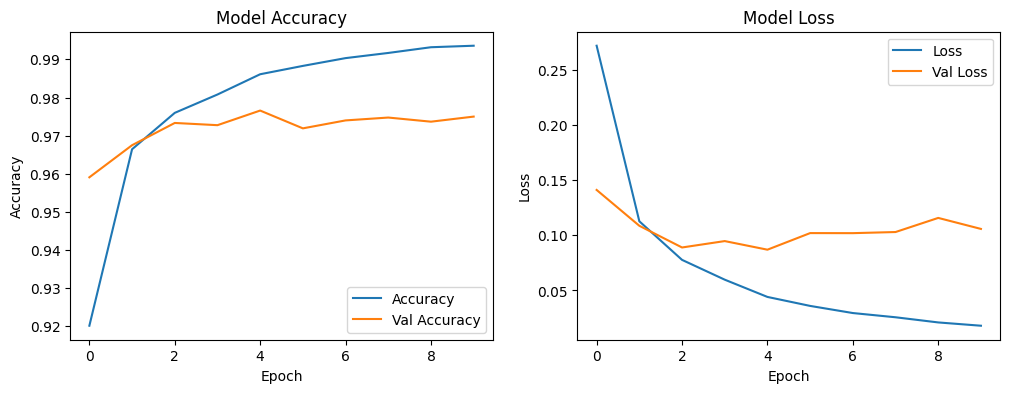

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


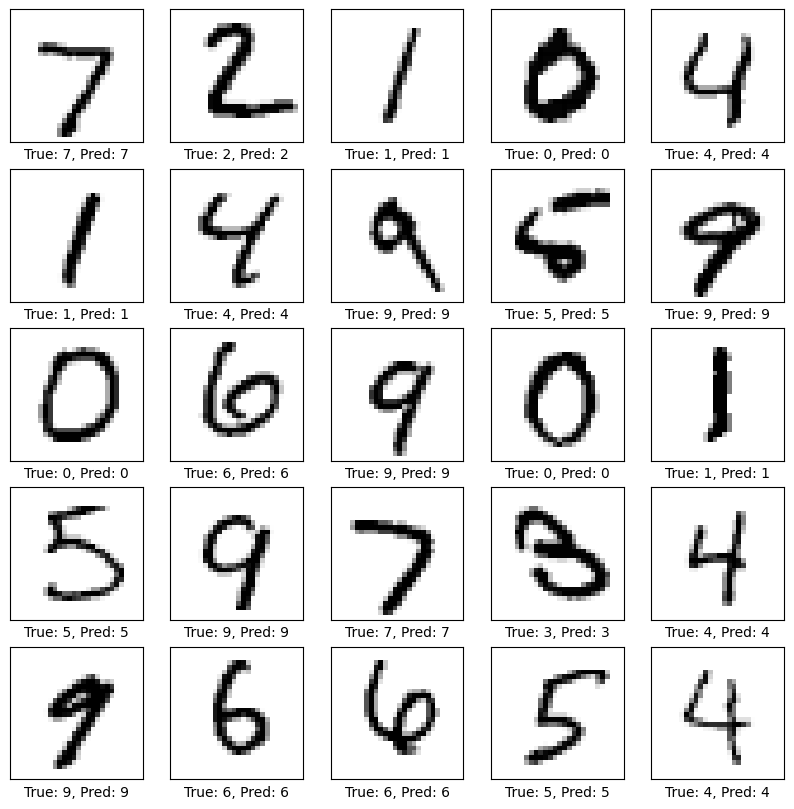

In [ ]:
#mnist data visualization
# Install necessary libraries
!pip install tensorflow matplotlib

# Step 3: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Step 4: Load and Prepare the Data
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the input data
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 5: Build the Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 6: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Train the Model
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

# Step 8: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

# Step 9: Data Visualization
# Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Model Loss')

plt.show()

# Visualize some predictions
predictions = model.predict(x_test)

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(f"True: {np.argmax(y_test[i])}, Pred: {np.argmax(predictions[i])}")
plt.show()

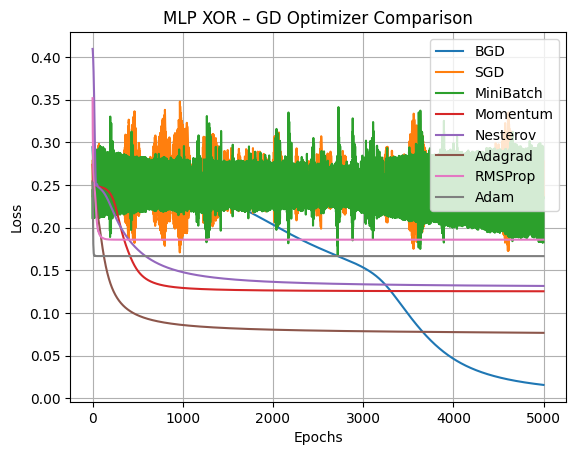

In [ ]:
# 14
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam)
# for learning XOR operation.

# ==========================================================
# MLP on XOR using Different Gradient Descent Optimizers
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR
# -----------------------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# Network Parameters
# -----------------------------
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
learning_rate = 0.1
epochs = 5000
batch_size = 2
np.random.seed(42)

# -----------------------------
# Initialize Weights
# -----------------------------
def init_weights():
    W1 = np.random.randn(input_neurons, hidden_neurons)
    b1 = np.random.randn(1, hidden_neurons)
    W2 = np.random.randn(hidden_neurons, output_neurons)
    b2 = np.random.randn(1, output_neurons)
    return W1, b1, W2, b2

# -----------------------------
# Forward + Backward
# -----------------------------
def forward_backward(Xb, yb, W1, b1, W2, b2):
    h_in = np.dot(Xb, W1) + b1
    h_out = sigmoid(h_in)
    f_in = np.dot(h_out, W2) + b2
    y_pred = sigmoid(f_in)

    error = yb - y_pred
    loss = np.mean(error**2)

    d_out = error * sigmoid_derivative(y_pred)
    d_hid = d_out.dot(W2.T) * sigmoid_derivative(h_out)

    return loss, h_out, d_out, d_hid

# ==========================================================
# Optimizers
# ==========================================================

def BGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * X.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def SGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        i = np.random.randint(len(X))
        loss,h_out,d_out,d_hid = forward_backward(X[i:i+1],y[i:i+1],W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * d_out
        W1 += learning_rate * X[i:i+1].T.dot(d_hid)
        b1 += learning_rate * d_hid

        loss_hist.append(loss)
    return loss_hist

def MiniBatchGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        idx = np.random.choice(len(X),batch_size,replace=False)
        Xb,yb = X[idx],y[idx]

        loss,h_out,d_out,d_hid = forward_backward(Xb,yb,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * Xb.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def Momentum(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=vb1=vb2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vb2 = beta*vb2 + learning_rate*np.sum(d_out,axis=0)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)
        vb1 = beta*vb1 + learning_rate*np.sum(d_hid,axis=0)

        W2 += vW2; b2 += vb2
        W1 += vW1; b1 += vb1

        loss_hist.append(loss)
    return loss_hist

def Nesterov(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=0
    loss_hist=[]

    for _ in range(epochs):
        W1n = W1 + beta*vW1
        W2n = W2 + beta*vW2

        loss,h_out,d_out,d_hid = forward_backward(X,y,W1n,b1,W2n,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)

        W2 += vW2
        W1 += vW1

        loss_hist.append(loss)
    return loss_hist

def Adagrad(eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    GW1=GW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        GW2 += gW2**2
        GW1 += gW1**2

        W2 += learning_rate * gW2 / (np.sqrt(GW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(GW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def RMSProp(beta=0.9, eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    EW1=EW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        EW2 = beta*EW2 + (1-beta)*(gW2**2)
        EW1 = beta*EW1 + (1-beta)*(gW1**2)

        W2 += learning_rate * gW2 / (np.sqrt(EW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(EW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def Adam(beta1=0.9,beta2=0.999,eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    mW1=vW1=mW2=vW2=0
    loss_hist=[]

    for t in range(1,epochs+1):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        mW2 = beta1*mW2 + (1-beta1)*gW2
        vW2 = beta2*vW2 + (1-beta2)*(gW2**2)
        mW1 = beta1*mW1 + (1-beta1)*gW1
        vW1 = beta2*vW1 + (1-beta2)*(gW1**2)

        W2 += learning_rate * mW2 / (np.sqrt(vW2)+eps)
        W1 += learning_rate * mW1 / (np.sqrt(vW1)+eps)

        loss_hist.append(loss)
    return loss_hist

# ==========================================================
# Plot Comparison
# ==========================================================

plt.plot(BGD(), label="BGD")
plt.plot(SGD(), label="SGD")
plt.plot(MiniBatchGD(), label="MiniBatch")
plt.plot(Momentum(), label="Momentum")
plt.plot(Nesterov(), label="Nesterov")
plt.plot(Adagrad(), label="Adagrad")
plt.plot(RMSProp(), label="RMSProp")
plt.plot(Adam(), label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP XOR – GD Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model function
def create_model(opt):
    model = Sequential()
    model.add(Flatten(input_shape=(32,32,3)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

# Optimizers
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(),
    "RMSProp": RMSprop(),
    "Adadelta": Adadelta(),
    "Adam": Adam()
}

# Train and compare
for name, opt in optimizers.items():
    print("\nOptimizer:", name)

    model = create_model(opt)
    model.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Test Accuracy:", acc)


Optimizer: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2927 - loss: 1.9881
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3554 - loss: 1.8345
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3805 - loss: 1.7763
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3957 - loss: 1.7352
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4074 - loss: 1.7016
Test Accuracy: 0.413100004196167

Optimizer: Momentum
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3270 - loss: 1.8746
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3945 - loss: 1.7026
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4233 - loss: 1.6356
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4360 - loss: 1.5971
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4516 - loss: 1.5596
Test Accuracy: 0.45100000500679016

Optimizer: Nesterov
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━

#week 5

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models, regularizers

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8198 - loss: 1.2675 - val_accuracy: 0.9148 - val_loss: 0.5624
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.5446 - val_accuracy: 0.9258 - val_loss: 0.4749
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9269 - loss: 0.4759 - val_accuracy: 0.9422 - val_loss: 0.4199
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9316 - loss: 0.4370 - val_accuracy: 0.9465 - val_loss: 0.3844
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9365 - loss: 0.4076 - val_accuracy: 0.9410 - val_loss: 0.3850
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9393 - loss: 0.3883 - val_accuracy: 0.9432 - val_loss: 0.3741
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9445 - loss: 0.3661 - val_accuracy: 0.9499 - val_loss: 0.3444
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9454 - loss: 0.3512 - 

In [ ]:
from IPython.display import Image
Image(url="https://miro.medium.com/max/1200/1*iWQzxhVlvadk6VAJjsgXgg.png", width=800, height=500)

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to 784 vector
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build model (Same as before + Dropout added)
def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dropout(0.3),              # 🔹 Dropout added
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),              # 🔹 Dropout added
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 20
batch_size = 256

# Train model (NO Early Stopping)
history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5427 - loss: 1.3786 - val_accuracy: 0.9197 - val_loss: 0.2800
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8768 - loss: 0.4149 - val_accuracy: 0.9410 - val_loss: 0.2040
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9030 - loss: 0.3223 - val_accuracy: 0.9490 - val_loss: 0.1769
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9197 - loss: 0.2809 - val_accuracy: 0.9541 - val_loss: 0.1554
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9279 - loss: 0.2465 - val_accuracy: 0.9597 - val_loss: 0.1406
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9312 - loss: 0.2313 - val_accuracy: 0.9621 - val_loss: 0.1309
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9390 - loss: 0.2119 - val_accuracy: 0.9643 - val_loss: 0.1231
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9428 - loss: 0.1916 - val_accuracy: 0

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to 784 vector
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ===============================
# 🔹 Add Noise to INPUTS
# ===============================
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# ===============================
# 🔹 Add Noise to OUTPUTS (Label Noise)
# Randomly flip 10% of labels
# ===============================
noise_ratio = 0.1
num_samples = int(noise_ratio * y_train.shape[0])

random_indices = np.random.choice(y_train.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 10)
    y_train[idx] = to_categorical(random_label, 10)

# ===============================
# Build Model (same as original)
# ===============================
def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model using noisy inputs and noisy labels
history = model.fit(
    x_train_noisy,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

# Evaluate on clean test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6105 - loss: 1.4062 - val_accuracy: 0.8174 - val_loss: 0.8211
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8216 - loss: 0.8128 - val_accuracy: 0.8369 - val_loss: 0.7565
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8418 - loss: 0.7353 - val_accuracy: 0.8508 - val_loss: 0.7209
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8577 - loss: 0.6803 - val_accuracy: 0.8553 - val_loss: 0.7068
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8651 - loss: 0.6492 - val_accuracy: 0.8562 - val_loss: 0.7014
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8694 - loss: 0.6249 - val_accuracy: 0.8585 - val_loss: 0.6932
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8764 - loss: 0.5975 - val_accuracy: 0.8608 - val_loss: 0.6935
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8778 - loss: 0.5865 - val_accura

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Shared Layer
shared_dense = Dense(64, activation='relu')

# Two inputs
input1 = Input(shape=(784,))
input2 = Input(shape=(784,))

# Apply SAME layer (parameter sharing)
encoded1 = shared_dense(input1)
encoded2 = shared_dense(input2)

# Merge
merged = Concatenate()([encoded1, encoded2])
output = Dense(10, activation='softmax')(merged)

model = Model(inputs=[input1, input2], outputs=output)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (using same data twice just for demo)
model.fit([x_train, x_train], y_train,
          epochs=5,
          batch_size=256,
          validation_split=0.2)

test_loss, test_acc = model.evaluate([x_test, x_test], y_test)
print("Test accuracy (Parameter Sharing):", test_acc)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7276 - loss: 0.9512 - val_accuracy: 0.9235 - val_loss: 0.2735
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9233 - loss: 0.2734 - val_accuracy: 0.9420 - val_loss: 0.2134
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9418 - loss: 0.2078 - val_accuracy: 0.9509 - val_loss: 0.1806
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9541 - loss: 0.1652 - val_accuracy: 0.9550 - val_loss: 0.1596
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9580 - loss: 0.1429 - val_accuracy: 0.9559 - val_loss: 0.1488
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9535 - loss: 0.1646
Test accuracy (Parameter Sharing): 0.9589999914169312


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# ==================================
# 🔹 Model 1: Simple Dense
# ==================================
model1 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Model 2: Medium Dense (NEW)
# ==================================
model2 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Model 3: Deeper Dense
# ==================================
model3 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.fit(x_train, y_train_cat,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Individual Model Accuracies
# ==================================
print("Model 1 Accuracy:", model1.evaluate(x_test, y_test_cat, verbose=0)[1])
print("Model 2 Accuracy:", model2.evaluate(x_test, y_test_cat, verbose=0)[1])
print("Model 3 Accuracy:", model3.evaluate(x_test, y_test_cat, verbose=0)[1])

# ==================================
# 🔹 Ensemble (Soft Voting)
# ==================================

pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)
pred3 = model3.predict(x_test)

# Average predictions
ensemble_pred = (pred1 + pred2 + pred3) / 3

# Convert probabilities to class labels
ensemble_classes = np.argmax(ensemble_pred, axis=1)

# Compute ensemble accuracy
ensemble_accuracy = np.mean(ensemble_classes == y_test)

print("Ensemble Accuracy:", ensemble_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 Accuracy: 0.9581999778747559
Model 2 Accuracy: 0.9677000045776367
Model 3 Accuracy: 0.9721999764442444
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Ensemble Accuracy: 0.9716


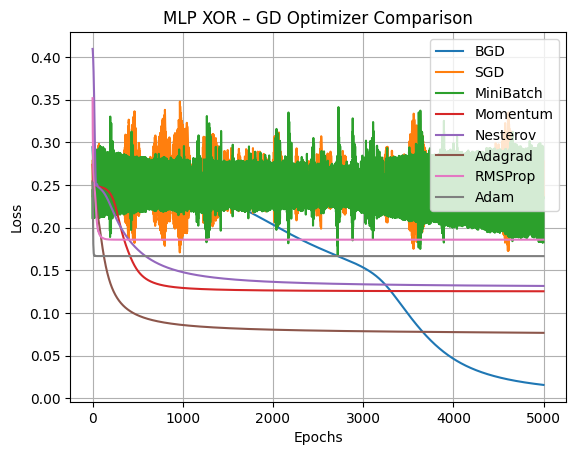

In [ ]:
# 14
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam)
# for learning XOR operation.

# ==========================================================
# MLP on XOR using Different Gradient Descent Optimizers
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR
# -----------------------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# Network Parameters
# -----------------------------
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
learning_rate = 0.1
epochs = 5000
batch_size = 2
np.random.seed(42)

# -----------------------------
# Initialize Weights
# -----------------------------
def init_weights():
    W1 = np.random.randn(input_neurons, hidden_neurons)
    b1 = np.random.randn(1, hidden_neurons)
    W2 = np.random.randn(hidden_neurons, output_neurons)
    b2 = np.random.randn(1, output_neurons)
    return W1, b1, W2, b2

# -----------------------------
# Forward + Backward
# -----------------------------
def forward_backward(Xb, yb, W1, b1, W2, b2):
    h_in = np.dot(Xb, W1) + b1
    h_out = sigmoid(h_in)
    f_in = np.dot(h_out, W2) + b2
    y_pred = sigmoid(f_in)

    error = yb - y_pred
    loss = np.mean(error**2)

    d_out = error * sigmoid_derivative(y_pred)
    d_hid = d_out.dot(W2.T) * sigmoid_derivative(h_out)

    return loss, h_out, d_out, d_hid

# ==========================================================
# Optimizers
# ==========================================================

def BGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * X.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def SGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        i = np.random.randint(len(X))
        loss,h_out,d_out,d_hid = forward_backward(X[i:i+1],y[i:i+1],W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * d_out
        W1 += learning_rate * X[i:i+1].T.dot(d_hid)
        b1 += learning_rate * d_hid

        loss_hist.append(loss)
    return loss_hist

def MiniBatchGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        idx = np.random.choice(len(X),batch_size,replace=False)
        Xb,yb = X[idx],y[idx]

        loss,h_out,d_out,d_hid = forward_backward(Xb,yb,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * Xb.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def Momentum(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=vb1=vb2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vb2 = beta*vb2 + learning_rate*np.sum(d_out,axis=0)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)
        vb1 = beta*vb1 + learning_rate*np.sum(d_hid,axis=0)

        W2 += vW2; b2 += vb2
        W1 += vW1; b1 += vb1

        loss_hist.append(loss)
    return loss_hist

def Nesterov(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=0
    loss_hist=[]

    for _ in range(epochs):
        W1n = W1 + beta*vW1
        W2n = W2 + beta*vW2

        loss,h_out,d_out,d_hid = forward_backward(X,y,W1n,b1,W2n,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)

        W2 += vW2
        W1 += vW1

        loss_hist.append(loss)
    return loss_hist

def Adagrad(eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    GW1=GW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        GW2 += gW2**2
        GW1 += gW1**2

        W2 += learning_rate * gW2 / (np.sqrt(GW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(GW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def RMSProp(beta=0.9, eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    EW1=EW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        EW2 = beta*EW2 + (1-beta)*(gW2**2)
        EW1 = beta*EW1 + (1-beta)*(gW1**2)

        W2 += learning_rate * gW2 / (np.sqrt(EW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(EW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def Adam(beta1=0.9,beta2=0.999,eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    mW1=vW1=mW2=vW2=0
    loss_hist=[]

    for t in range(1,epochs+1):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        mW2 = beta1*mW2 + (1-beta1)*gW2
        vW2 = beta2*vW2 + (1-beta2)*(gW2**2)
        mW1 = beta1*mW1 + (1-beta1)*gW1
        vW1 = beta2*vW1 + (1-beta2)*(gW1**2)

        W2 += learning_rate * mW2 / (np.sqrt(vW2)+eps)
        W1 += learning_rate * mW1 / (np.sqrt(vW1)+eps)

        loss_hist.append(loss)
    return loss_hist

# ==========================================================
# Plot Comparison
# ==========================================================

plt.plot(BGD(), label="BGD")
plt.plot(SGD(), label="SGD")
plt.plot(MiniBatchGD(), label="MiniBatch")
plt.plot(Momentum(), label="Momentum")
plt.plot(Nesterov(), label="Nesterov")
plt.plot(Adagrad(), label="Adagrad")
plt.plot(RMSProp(), label="RMSProp")
plt.plot(Adam(), label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP XOR – GD Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()

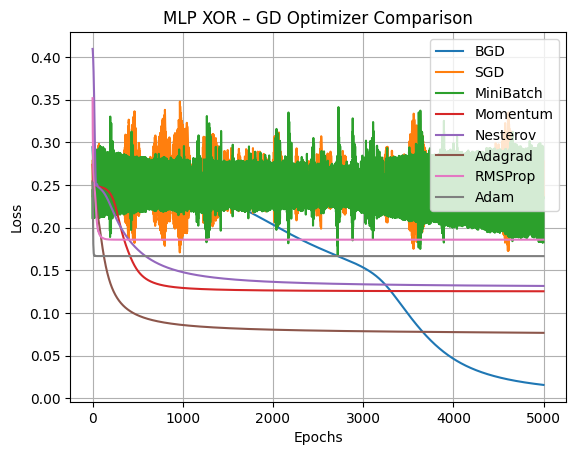

In [ ]:
# 14
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam)
# for learning XOR operation.

# ==========================================================
# MLP on XOR using Different Gradient Descent Optimizers
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR
# -----------------------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# Network Parameters
# -----------------------------
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
learning_rate = 0.1
epochs = 5000
batch_size = 2
np.random.seed(42)

# -----------------------------
# Initialize Weights
# -----------------------------
def init_weights():
    W1 = np.random.randn(input_neurons, hidden_neurons)
    b1 = np.random.randn(1, hidden_neurons)
    W2 = np.random.randn(hidden_neurons, output_neurons)
    b2 = np.random.randn(1, output_neurons)
    return W1, b1, W2, b2

# -----------------------------
# Forward + Backward
# -----------------------------
def forward_backward(Xb, yb, W1, b1, W2, b2):
    h_in = np.dot(Xb, W1) + b1
    h_out = sigmoid(h_in)
    f_in = np.dot(h_out, W2) + b2
    y_pred = sigmoid(f_in)

    error = yb - y_pred
    loss = np.mean(error**2)

    d_out = error * sigmoid_derivative(y_pred)
    d_hid = d_out.dot(W2.T) * sigmoid_derivative(h_out)

    return loss, h_out, d_out, d_hid

# ==========================================================
# Optimizers
# ==========================================================

def BGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * X.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def SGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        i = np.random.randint(len(X))
        loss,h_out,d_out,d_hid = forward_backward(X[i:i+1],y[i:i+1],W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * d_out
        W1 += learning_rate * X[i:i+1].T.dot(d_hid)
        b1 += learning_rate * d_hid

        loss_hist.append(loss)
    return loss_hist

def MiniBatchGD():
    W1,b1,W2,b2 = init_weights()
    loss_hist = []

    for _ in range(epochs):
        idx = np.random.choice(len(X),batch_size,replace=False)
        Xb,yb = X[idx],y[idx]

        loss,h_out,d_out,d_hid = forward_backward(Xb,yb,W1,b1,W2,b2)

        W2 += learning_rate * h_out.T.dot(d_out)
        b2 += learning_rate * np.sum(d_out,axis=0)
        W1 += learning_rate * Xb.T.dot(d_hid)
        b1 += learning_rate * np.sum(d_hid,axis=0)

        loss_hist.append(loss)
    return loss_hist

def Momentum(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=vb1=vb2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vb2 = beta*vb2 + learning_rate*np.sum(d_out,axis=0)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)
        vb1 = beta*vb1 + learning_rate*np.sum(d_hid,axis=0)

        W2 += vW2; b2 += vb2
        W1 += vW1; b1 += vb1

        loss_hist.append(loss)
    return loss_hist

def Nesterov(beta=0.9):
    W1,b1,W2,b2 = init_weights()
    vW1=vW2=0
    loss_hist=[]

    for _ in range(epochs):
        W1n = W1 + beta*vW1
        W2n = W2 + beta*vW2

        loss,h_out,d_out,d_hid = forward_backward(X,y,W1n,b1,W2n,b2)

        vW2 = beta*vW2 + learning_rate*h_out.T.dot(d_out)
        vW1 = beta*vW1 + learning_rate*X.T.dot(d_hid)

        W2 += vW2
        W1 += vW1

        loss_hist.append(loss)
    return loss_hist

def Adagrad(eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    GW1=GW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        GW2 += gW2**2
        GW1 += gW1**2

        W2 += learning_rate * gW2 / (np.sqrt(GW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(GW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def RMSProp(beta=0.9, eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    EW1=EW2=0
    loss_hist=[]

    for _ in range(epochs):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        EW2 = beta*EW2 + (1-beta)*(gW2**2)
        EW1 = beta*EW1 + (1-beta)*(gW1**2)

        W2 += learning_rate * gW2 / (np.sqrt(EW2)+eps)
        W1 += learning_rate * gW1 / (np.sqrt(EW1)+eps)

        loss_hist.append(loss)
    return loss_hist

def Adam(beta1=0.9,beta2=0.999,eps=1e-8):
    W1,b1,W2,b2 = init_weights()
    mW1=vW1=mW2=vW2=0
    loss_hist=[]

    for t in range(1,epochs+1):
        loss,h_out,d_out,d_hid = forward_backward(X,y,W1,b1,W2,b2)
        gW2 = h_out.T.dot(d_out)
        gW1 = X.T.dot(d_hid)

        mW2 = beta1*mW2 + (1-beta1)*gW2
        vW2 = beta2*vW2 + (1-beta2)*(gW2**2)
        mW1 = beta1*mW1 + (1-beta1)*gW1
        vW1 = beta2*vW1 + (1-beta2)*(gW1**2)

        W2 += learning_rate * mW2 / (np.sqrt(vW2)+eps)
        W1 += learning_rate * mW1 / (np.sqrt(vW1)+eps)

        loss_hist.append(loss)
    return loss_hist

# ==========================================================
# Plot Comparison
# ==========================================================

plt.plot(BGD(), label="BGD")
plt.plot(SGD(), label="SGD")
plt.plot(MiniBatchGD(), label="MiniBatch")
plt.plot(Momentum(), label="Momentum")
plt.plot(Nesterov(), label="Nesterov")
plt.plot(Adagrad(), label="Adagrad")
plt.plot(RMSProp(), label="RMSProp")
plt.plot(Adam(), label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP XOR – GD Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Base Model Function
# -----------------------------
def create_model(reg=None, dropout=False, noise=False):
    model = Sequential()

    model.add(Flatten(input_shape=(32,32,3)))

    if noise:
        model.add(GaussianNoise(0.1))   # Adding noise

    model.add(Dense(128, activation='relu', kernel_regularizer=reg))

    if dropout:
        model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# -----------------------------
# 1. L2 Regularization
# -----------------------------
print("\n--- L2 Regularization ---")
model_l2 = create_model(reg=l2(0.001))
model_l2.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)
print("L2 Accuracy:", model_l2.evaluate(X_test, y_test, verbose=0)[1])


# -----------------------------
# 2. Dropout
# -----------------------------
print("\n--- Dropout ---")
model_dropout = create_model(dropout=True)
model_dropout.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)
print("Dropout Accuracy:", model_dropout.evaluate(X_test, y_test, verbose=0)[1])


# -----------------------------
# 3. Adding Noise
# -----------------------------
print("\n--- Noise Injection ---")
model_noise = create_model(noise=True)
model_noise.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)
print("Noise Accuracy:", model_noise.evaluate(X_test, y_test, verbose=0)[1])


# -----------------------------
# 4. Early Stopping
# -----------------------------
print("\n--- Early Stopping ---")
early = EarlyStopping(monitor='val_loss', patience=2)

model_early = create_model()
model_early.fit(X_train, y_train,
                validation_split=0.2,
                epochs=20,
                batch_size=128,
                callbacks=[early],
                verbose=1)

print("EarlyStopping Accuracy:", model_early.evaluate(X_test, y_test, verbose=0)[1])


# -----------------------------
# 5. Data Augmentation
# -----------------------------
print("\n--- Data Augmentation ---")
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

model_aug = create_model()

model_aug.fit(datagen.flow(X_train, y_train, batch_size=128),
              epochs=5,
              verbose=1)

print("Augmentation Accuracy:", model_aug.evaluate(X_test, y_test, verbose=0)[1])


# -----------------------------
# 6. Ensemble Method
# -----------------------------
print("\n--- Ensemble ---")

model1 = create_model()
model2 = create_model()

model1.fit(X_train, y_train, epochs=5, batch_size=128, verbose=0)
model2.fit(X_train, y_train, epochs=5, batch_size=128, verbose=0)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

ensemble_pred = (pred1 + pred2) / 2
ensemble_acc = np.mean(np.argmax(ensemble_pred, axis=1) == np.argmax(y_test, axis=1))

print("Ensemble Accuracy:", ensemble_acc)


--- L2 Regularization ---
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.3086 - loss: 2.0766
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3702 - loss: 1.8421
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3903 - loss: 1.7709
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4010 - loss: 1.7374
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4138 - loss: 1.7048
L2 Accuracy: 0.4180999994277954

--- Dropout ---
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1526 - loss: 2.2313
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1710 - loss: 2.1572
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1811 - loss: 2.1163
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1835 - loss: 2.1117
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1852 - loss: 2.1072
Dropout Accuracy: 0.2793999910354614

--- Noise Injection ---


#WEEK 6

In [1]:
#cnn
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

model = Sequential([
    Input(shape=(28,28,1)), # Recommended way to specify input shape
    Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'),
    MaxPool2D(pool_size=(1,1)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 123ms/step - accuracy: 0.9370 - loss: 0.2153 - val_accuracy: 0.9749 - val_loss: 0.0825
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.9796 - loss: 0.0689 - val_accuracy: 0.9799 - val_loss: 0.0613
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9875 - loss: 0.0426 - val_accuracy: 0.9832 - val_loss: 0.0530
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9919 - loss: 0.0270 - val_accuracy: 0.9811 - val_loss: 0.0601
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.9945 - loss: 0.0183 - val_accuracy: 0.9813 - val_loss: 0.0581
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 143ms/step - accuracy: 0.9963 - loss: 0.0128 - val_accuracy: 0.9796 - val_loss: 0.0659
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9974 - loss: 0

In [ ]:
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
# Normalize data
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
# One-hot encoding
n_classes = 10
print("Shape before encoding:", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after encoding:", Y_train.shape)
# Build CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train model
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape before encoding: (50000, 1)
Shape after encoding: (50000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.3748 - loss: 1.7050 - val_accuracy: 0.5146 - val_loss: 1.3775
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.4941 - loss: 1.4056 - val_accuracy: 0.5697 - val_loss: 1.2150
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.5441 - loss: 1.2714 - val_accuracy: 0.5944 - val_loss: 1.1515
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.5765 - loss: 1.1888 - val_accuracy: 0.6372 - val_loss: 1.0444
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 95s 167ms/step - accuracy: 0.6094 - loss: 1.1110 - val_accuracy: 0.6602 - val_loss: 0.9807
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 164ms/step - accuracy: 0.6260 - loss: 1.0661 - val_accuracy: 0.6571 - val_loss: 0.9798
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 132ms/step - accuracy: 0.6416 - loss: 1.0204 - val_accuracy: 0.6736 - val_loss: 0.9266
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.6576 - loss: 0

#WEEK - 7

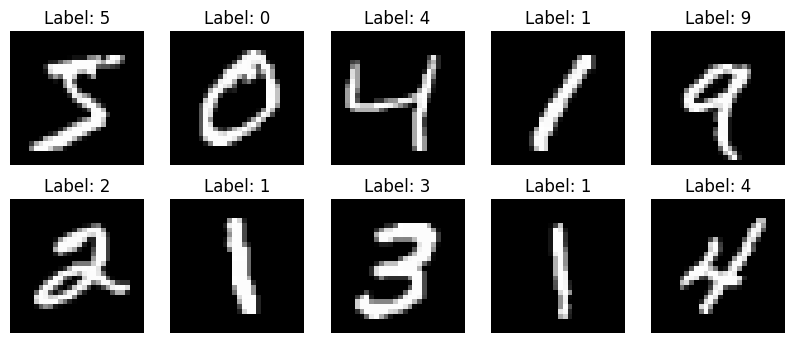

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8843 - loss: 0.3999 - val_accuracy: 0.9484 - val_loss: 0.1778
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9531 - loss: 0.1545 - val_accuracy: 0.9681 - val_loss: 0.1121
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.1008 - val_accuracy: 0.9733 - val_loss: 0.0877
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9771 - loss: 0.0738 - val_accuracy: 0.9790 - val_loss: 0.0687
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9819 - loss: 0.0591 - val_accuracy: 0.9803 - val_loss: 0.0677
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9850 - loss: 0.0490 - val_accuracy: 0.9796 - val_loss: 0.0623
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9870 - loss: 0.0411 - val_accuracy: 0.9835 - val_loss: 0.0576
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9894 - loss: 0.0360 - val_accuracy: 

In [ ]:
#LENET
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt
#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
#Visualize The Training Data
plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot
#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.
# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]
# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]
#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0
#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)
#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)
#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()
# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))
# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))
# Flatten The Layer
LeNet5_Model.add(Flatten())
# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))
#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#Check Model Summary
LeNet5_Model.summary()
#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))
#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

In [ ]:
# ALEX NET
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear previous session to free memory
keras.backend.clear_session()

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess images
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Use 112x112 instead of 224x224 (reduces memory usage)
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)  # Convert grayscale to RGB
    image = tf.image.resize(image, (112, 112))  # Resize to 112x112
    return image / 255.0, tf.one_hot(label, 10)

# Create dataset pipeline with smaller batch size (8 or 16)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

# Enable mixed precision (reduces memory usage)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Build AlexNet model (with 112x112 input shape)
model = Sequential()

# Layer 1: Convolution + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile model (use Adam optimizer and mixed precision)
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train model (with reduced batch size)
history = model.fit(train_dataset, epochs=3, validation_data=test_dataset)

# Evaluate model
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 84s 9ms/step - accuracy: 0.1107 - loss: 2.3045 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 2/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 9ms/step - accuracy: 0.1123 - loss: 2.3015 - val_accuracy: 0.1028 - val_loss: 2.3014
Epoch 3/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1124 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3011
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1135 - loss: 2.3011
Test accuracy: 0.11349999904632568


In [ ]:
# ZFNET (Fixed Version)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

keras.backend.clear_session()

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocessing function
def process_image(image, label):
    image = tf.expand_dims(image, axis=-1)             # (28,28,1)
    image = tf.image.grayscale_to_rgb(image)           # (28,28,3)
    image = tf.image.resize(image, (64, 64))           # (64,64,3)
    return image / 255.0, tf.one_hot(label, 10)

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(16)

#  Model
model = Sequential()

model.add(Conv2D(96, (7,7), strides=2, activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((3,3), strides=2))

model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(MaxPooling2D((3,3), strides=2))

model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D((3,3), strides=2))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_dataset,
          epochs=5,
          validation_data=test_dataset)

# Evaluate
model.evaluate(test_dataset)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - accuracy: 0.9420 - loss: 0.1878 - val_accuracy: 0.9747 - val_loss: 0.0918
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9794 - loss: 0.0800 - val_accuracy: 0.9679 - val_loss: 0.1476
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - accuracy: 0.9826 - loss: 0.0710 - val_accuracy: 0.9820 - val_loss: 0.0690
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - accuracy: 0.9845 - loss: 0.0619 - val_accuracy: 0.9838 - val_loss: 0.0545
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9859 - loss: 0.0579 - val_accuracy: 0.9850 - val_loss: 0.0669
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9850 - loss: 0.0669


[0.06691061705350876, 0.9850000143051147]

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

# Clear session
keras.backend.clear_session()

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Reduce dataset size (FASTER)
x_train = x_train[:10000]
y_train = y_train[:10000]

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model (NO RESIZE → faster)
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))   # Reduced from 512 → faster
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train (FAST)
model.fit(x_train, y_train, epochs=2, batch_size=32, validation_data=(x_test, y_test))

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("VGG Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 358ms/step - accuracy: 0.2663 - loss: 1.9458 - val_accuracy: 0.3562 - val_loss: 1.7357
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.4410 - loss: 1.5192 - val_accuracy: 0.4479 - val_loss: 1.5127
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.4479 - loss: 1.5127
VGG Accuracy: 0.4478999972343445


In [ ]:
# GOOGLENET
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

# Load dataset (CIFAR-10)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Resize to (64,64,3) because model expects 64x64
X_train = tf.image.resize(X_train, (64,64))
X_test = tf.image.resize(X_test, (64,64))

#One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Inception Module
def inception_module(x, f1, f3, f5):
    conv1 = Conv2D(f1, (1,1), activation='relu', padding='same')(x)
    conv3 = Conv2D(f3, (3,3), activation='relu', padding='same')(x)
    conv5 = Conv2D(f5, (5,5), activation='relu', padding='same')(x)
    pool = MaxPooling2D((3,3), strides=1, padding='same')(x)
    return concatenate([conv1, conv3, conv5, pool])

# Model Architecture
inputs = Input(shape=(64,64,3))

x = Conv2D(64, (7,7), strides=2, activation='relu', padding='same')(inputs)
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

x = inception_module(x, 32, 64, 16)
x = inception_module(x, 64, 128, 32)

x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

# Train (NO ERROR NOW)
model.fit(X_train, y_train,
          epochs=1,
          batch_size=32,
          validation_data=(X_test, y_test))

# Evaluate
model.evaluate(X_test, y_test)

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      9,472 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │      2,080 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │     25,616 │ max_pooling2d_6[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ max_pooling2d_6[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 16, 16,    │          0 │ conv2d_23[0][0],  │
│ (Concatenate)       │ 176)              │            │ conv2d_24[0][0],  │
│                     │                   │            │ conv2d_25[0][0],  │
│                     │                   │            │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │     11,328 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │    202,880 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │    140,832 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 176)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 400)              │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0],  │
│                     │                   │            │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 400)       │          0 │ concatenate_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10)        │      4,010 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 433,146 (1.65 MB)

 Trainable params: 433,146 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.3662 - loss: 1.7030 - val_accuracy: 0.4528 - val_loss: 1.4775
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4528 - loss: 1.4775


[1.4774854183197021, 0.4528000056743622]

In [ ]:
# RESNET (Simplified - Working Version)
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Activation, Add, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Resize to 64x64
X_train = tf.image.resize(X_train, (64,64))
X_test = tf.image.resize(X_test, (64,64))

#One-hot encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Residual Block
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same')(x)

    # Add shortcut
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Model
inputs = Input(shape=(64,64,3))

x = Conv2D(64, (3,3), padding='same')(inputs)
x = Activation('relu')(x)

x = residual_block(x, 64)
x = residual_block(x, 64)

x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

# Train (FIXED)
model.fit(X_train, y_train,
          epochs=1,
          batch_size=32,
          validation_data=(X_test, y_test))

# Evaluate
model.evaluate(X_test, y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ conv2d_4[0][0],   │
│                     │ 64)               │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_4[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │        650 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,154 (586.54 KB)

 Trainable params: 150,154 (586.54 KB)

 Non-trainable params: 0 (0.00 B)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 34ms/step - accuracy: 0.3046 - loss: 1.8430 - val_accuracy: 0.4114 - val_loss: 1.6073
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4114 - loss: 1.6073


[1.6072795391082764, 0.4113999903202057]

In [ ]:
# LENET CIFAR-10 (Fixed Version)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model
model = Sequential()

model.add(Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Conv2D(16, (5,5), activation='relu'))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(120, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

# compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, y_train,
          epochs=1,
          batch_size=128,
          validation_data=(X_test, y_test))

#  Evaluate
model.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3575 - loss: 1.7604 - val_accuracy: 0.4308 - val_loss: 1.5820
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4308 - loss: 1.5820


[1.5820127725601196, 0.4307999908924103]

In [ ]:
#ALEXNET CIFAR 10
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential()
model.add(Conv2D(96, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D())
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(384, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.4271 - loss: 1.5545 - val_accuracy: 0.5551 - val_loss: 1.2351
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6034 - loss: 1.1164 - val_accuracy: 0.6510 - val_loss: 0.9919
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6785 - loss: 0.9150 - val_accuracy: 0.6975 - val_loss: 0.8602
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7284 - loss: 0.7778 - val_accuracy: 0.7110 - val_loss: 0.8279
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7628 - loss: 0.6784 - val_accuracy: 0.7388 - val_loss: 0.7536
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7388 - loss: 0.7536


[0.7535907030105591, 0.7387999892234802]

In [ ]:
#ZFNET CIFAR 10
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model
model = Sequential()

model.add(Input(shape=(32,32,3)))  # Fix warning

model.add(Conv2D(96, (7,7), strides=2, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(256, (5,5), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(384, (3,3), activation='relu', padding='same'))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test))

# Evaluate
model.evaluate(X_test, y_test)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.4028 - loss: 1.6240 - val_accuracy: 0.5441 - val_loss: 1.2849
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5758 - loss: 1.1808 - val_accuracy: 0.5990 - val_loss: 1.1145
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6555 - loss: 0.9726 - val_accuracy: 0.6511 - val_loss: 0.9853
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7091 - loss: 0.8215 - val_accuracy: 0.6850 - val_loss: 0.9071
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7622 - loss: 0.6811 - val_accuracy: 0.6942 - val_loss: 0.8917
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6942 - loss: 0.8917


[0.8916997909545898, 0.6941999793052673]

In [ ]:
#VGGNET CIFAR 10
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.4714 - loss: 1.4633 - val_accuracy: 0.6050 - val_loss: 1.1169
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 527s 1s/step - accuracy: 0.6660 - loss: 0.9500 - val_accuracy: 0.6974 - val_loss: 0.8772
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 563s 1s/step - accuracy: 0.7438 - loss: 0.7312 - val_accuracy: 0.7343 - val_loss: 0.7526
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 544s 1s/step - accuracy: 0.7988 - loss: 0.5766 - val_accuracy: 0.7567 - val_loss: 0.7083
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.8460 - loss: 0.4441 - val_accuracy: 0.7582 - val_loss: 0.7566
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.7582 - loss: 0.7566


[0.7565682530403137, 0.7581999897956848]

In [ ]:
#GOOGLENET CIFAR 10
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Input
from tensorflow.keras.models import Model

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def inception_module(x):
    path1 = Conv2D(64, (1,1), activation='relu', padding='same')(x)
    path2 = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    path3 = Conv2D(64, (5,5), activation='relu', padding='same')(x)
    return Concatenate()([path1, path2, path3])

inputs = Input(shape=(32,32,3))
x = inception_module(inputs)
x = MaxPooling2D()(x)
x = inception_module(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=3, batch_size=128, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.4413 - loss: 1.5771 - val_accuracy: 0.5461 - val_loss: 1.2753
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5840 - loss: 1.1692 - val_accuracy: 0.6161 - val_loss: 1.0984
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.6556 - loss: 0.9809 - val_accuracy: 0.6391 - val_loss: 1.0137
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6391 - loss: 1.0137


[1.0137176513671875, 0.6391000151634216]

In [ ]:
#RESNET CIFAR 10
import tensorflow as tf
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, Add, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def res_block(x, filters):
    shortcut = x
    x = Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = Add()([x, shortcut])
    return tf.keras.activations.relu(x)

inputs = Input(shape=(32,32,3))
x = Conv2D(64, (3,3), padding='same')(inputs)
x = res_block(x, 64)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=2, batch_size=128, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.5125 - loss: 1.3681 - val_accuracy: 0.6385 - val_loss: 1.0333
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6810 - loss: 0.9153 - val_accuracy: 0.6924 - val_loss: 0.8856
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6924 - loss: 0.8856


[0.8855956196784973, 0.6923999786376953]

#week - 8

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3383 - val_loss: 0.2715
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2678 - val_loss: 0.2653
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2648 - val_loss: 0.2640
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2639 - val_loss: 0.2635
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2632 - val_loss: 0.2628
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2631 - val_loss: 0.2627
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2613 - val_loss: 0.2563
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2521 - val_loss: 0.2480
E

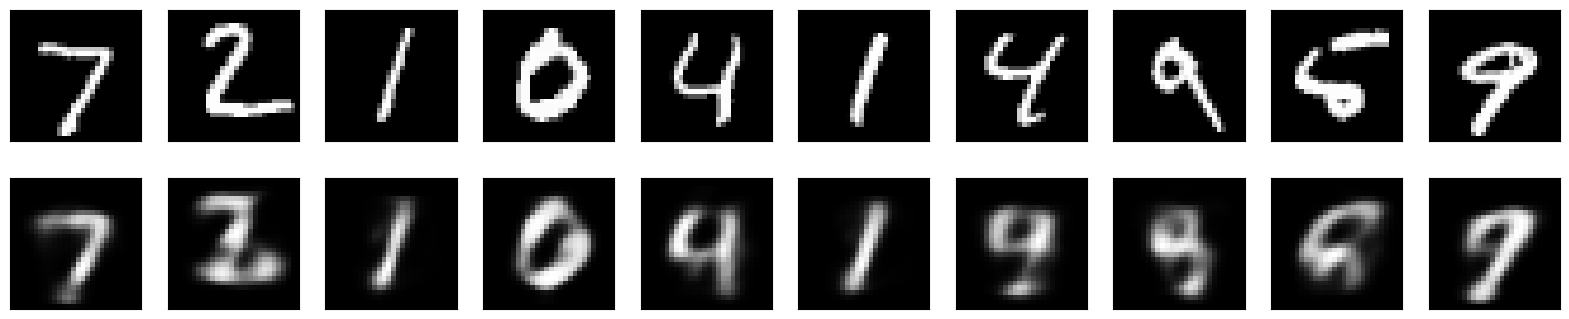

In [1]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2771 - val_loss: 0.1918
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1727 - val_loss: 0.1551
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1451 - val_loss: 0.1341
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1288 - val_loss: 0.1218
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1187 - val_loss: 0.1138
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1119 - val_loss: 0.1081
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1069 - val_loss: 0.1037
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1031 - val_loss: 0.1004
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1002 - val_loss: 0.0978
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0981 - val_loss: 0.0961
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


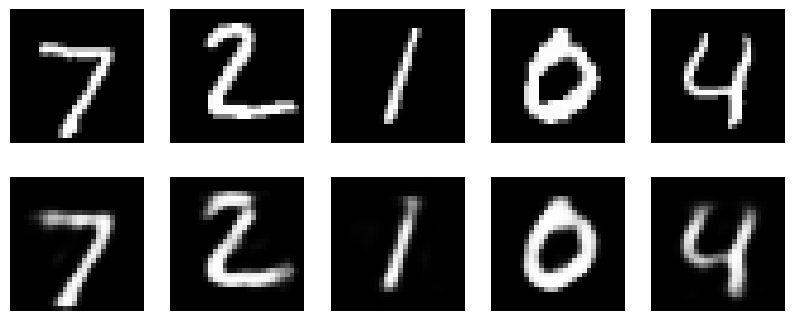

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize & reshape
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Model
input_img = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_img)  # compressed
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Test
decoded_imgs = autoencoder.predict(x_test)

# Display
plt.figure(figsize=(10,4))
for i in range(5):
    # original
    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray(); ax.axis('off')

    # reconstructed
    ax = plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray(); ax.axis('off')

plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.1372 - val_loss: 0.0811
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0750 - val_loss: 0.0703
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0690 - val_loss: 0.0675
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0670 - val_loss: 0.0661
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0660 - val_loss: 0.0653
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0654 - val_loss: 0.0649
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0647 - val_loss: 0.0643
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0644 - val_loss: 0.0643
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0642 - val_loss: 0.0640
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


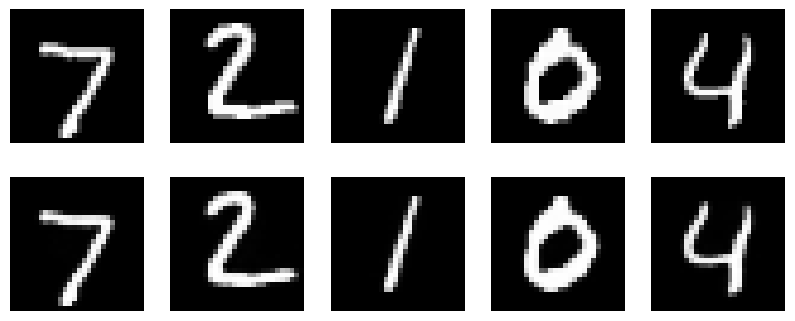

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Model (overcomplete)
input_img = Input(shape=(784,))
encoded = Dense(1024, activation='relu')(input_img)  # expanded
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Test
decoded_imgs = autoencoder.predict(x_test)

# Display
plt.figure(figsize=(10,4))
for i in range(5):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray(); ax.axis('off')

    ax = plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray(); ax.axis('off')

plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4303 - val_loss: 0.2980
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2658 - val_loss: 0.2409
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2317 - val_loss: 0.2233
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2196 - val_loss: 0.2143
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2117 - val_loss: 0.2074
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2055 - val_loss: 0.2021
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2008 - val_loss: 0.1979
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1973 - val_loss: 0.1950
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1945 - val_loss: 0.1923
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1922 - val_loss: 0.1902
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


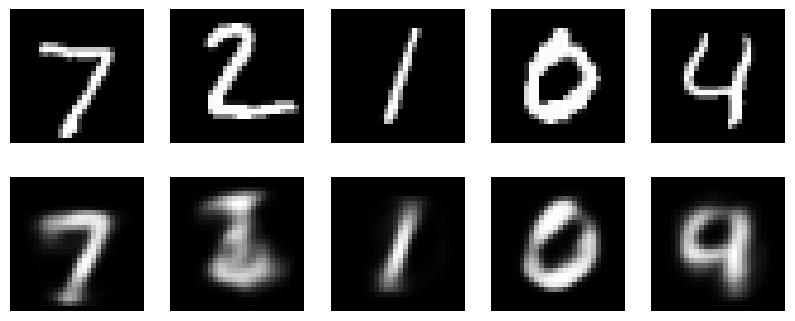

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Model with L1 regularization
input_img = Input(shape=(784,))
encoded = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Test
decoded_imgs = autoencoder.predict(x_test)

# Display
plt.figure(figsize=(10,4))
for i in range(5):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray(); ax.axis('off')

    ax = plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray(); ax.axis('off')

plt.show()